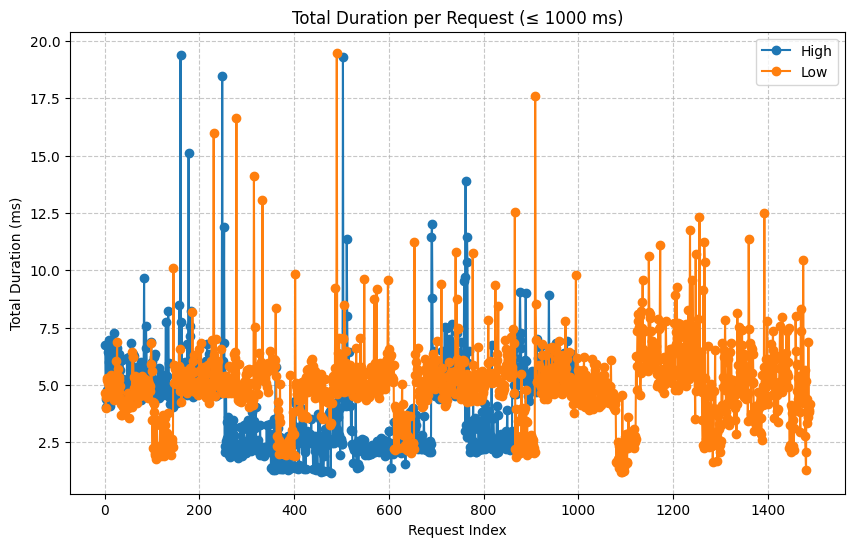

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
def process_trace_file(filename):
    """
    Load a JSON trace file and extract durations of spans 0 and 6.
    Returns a DataFrame with trigger, dispatcher, and total durations in milliseconds.
    """
    with open(filename) as f:
        data = json.load(f)
    
    results = []
    for trace in data['data']:
        trace_id = trace['traceID']
        spans = trace['spans']
        if len(spans) >= 7:
            trigger_ms = spans[0]['duration'] / 1000
            dispatcher_ms = spans[6]['duration'] / 1000
            total_ms = trigger_ms + dispatcher_ms
            results.append({
                'traceID': trace_id,
                'trigger_ms': trigger_ms,
                'dispatcher_ms': dispatcher_ms,
                'total_duration_ms': total_ms
            })
    return pd.DataFrame(results)

# Create DataFrame for High traces
df_high = process_trace_file('traces-1755701459390.json')

# Create DataFrame for Low traces
df_low = process_trace_file('traces-1755615767259-cloud-low-3.json')

# Display the DataFrames
# Filter out values > 1000 ms
df_high_filtered = df_high[df_high['total_duration_ms'] <= 20].reset_index(drop=True)
df_low_filtered = df_low[df_low['total_duration_ms'] <= 20].reset_index(drop=True)

# Assign request index
df_high_filtered['request_index'] = df_high_filtered.index + 1
df_low_filtered['request_index'] = df_low_filtered.index + 1

# Plot as two lines
plt.figure(figsize=(10, 6))
plt.plot(df_high_filtered['request_index'], df_high_filtered['total_duration_ms'], 
         marker='o', linestyle='-', label='High')
plt.plot(df_low_filtered['request_index'], df_low_filtered['total_duration_ms'], 
         marker='o', linestyle='-', label='Low')

plt.title('Total Duration per Request (≤ 1000 ms)')
plt.xlabel('Request Index')
plt.ylabel('Total Duration (ms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



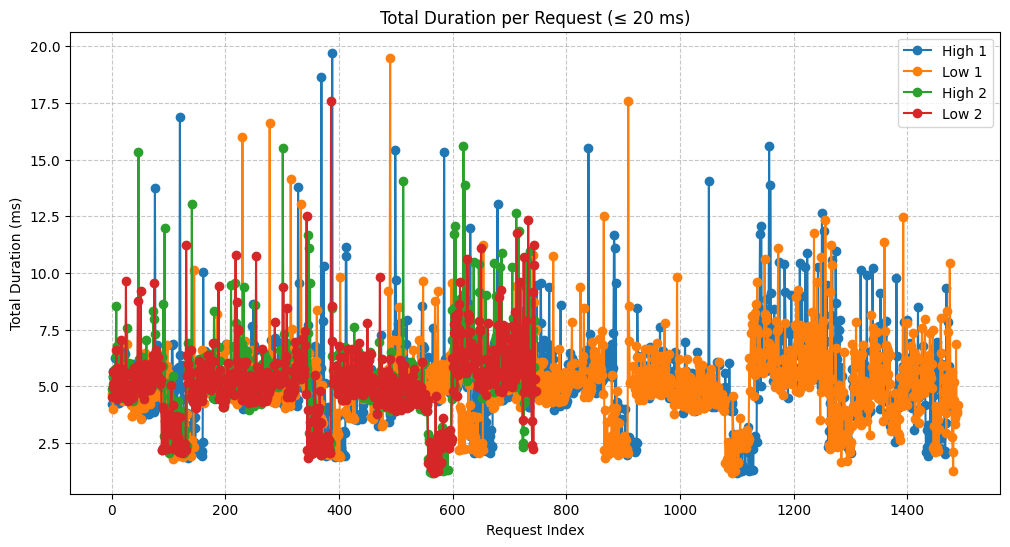

In [41]:
import json
import pandas as pd
import matplotlib.pyplot as plt

def process_trace_file(filename):
    """
    Load a JSON trace file and extract durations of spans 0 and 6.
    Returns a DataFrame with trigger, dispatcher, and total durations in milliseconds.
    """
    with open(filename) as f:
        data = json.load(f)
    
    results = []
    for trace in data['data']:
        trace_id = trace['traceID']
        spans = trace['spans']
        if len(spans) >= 7:
            trigger_ms = spans[0]['duration'] / 1000
            dispatcher_ms = spans[6]['duration'] / 1000
            total_ms = trigger_ms + dispatcher_ms
            results.append({
                'traceID': trace_id,
                'trigger_ms': trigger_ms,
                'dispatcher_ms': dispatcher_ms,
                'total_duration_ms': total_ms
            })
    return pd.DataFrame(results)

# List of trace files
files = [
    'traces-1755615729160-cloud-high-3.json',
    'traces-1755615767259-cloud-low-3.json',
    'traces-1755613029848-edge-high.json',   # replace with your actual filenames
    'traces-1755613073413-edge-low.json'
]

labels = ['High 1', 'Low 1', 'High 2', 'Low 2']

plt.figure(figsize=(12, 6))

for file, label in zip(files, labels):
    df = process_trace_file(file)
    # Filter out high values
    df_filtered = df[df['total_duration_ms'] <= 20].reset_index(drop=True)
    df_filtered['request_index'] = df_filtered.index + 1
    plt.plot(df_filtered['request_index'], df_filtered['total_duration_ms'],
             marker='o', linestyle='-', label=label)

plt.title('Total Duration per Request (≤ 20 ms)')
plt.xlabel('Request Index')
plt.ylabel('Total Duration (ms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


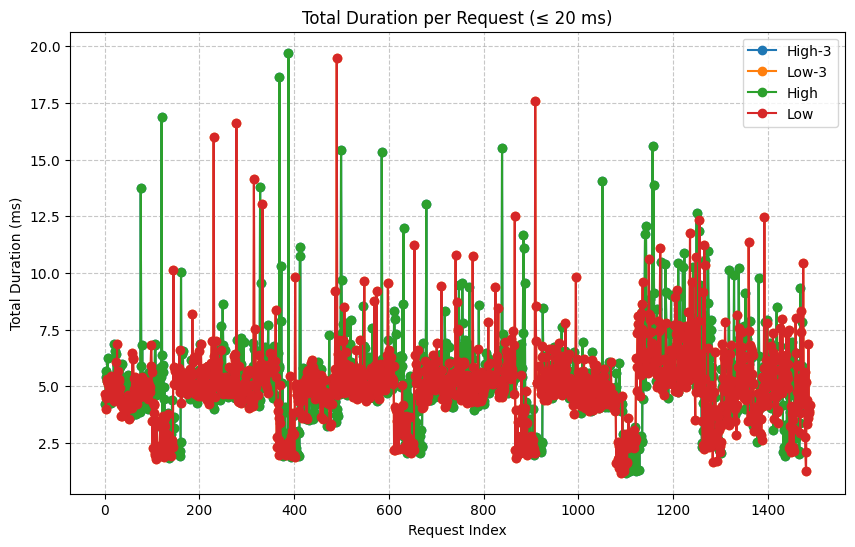

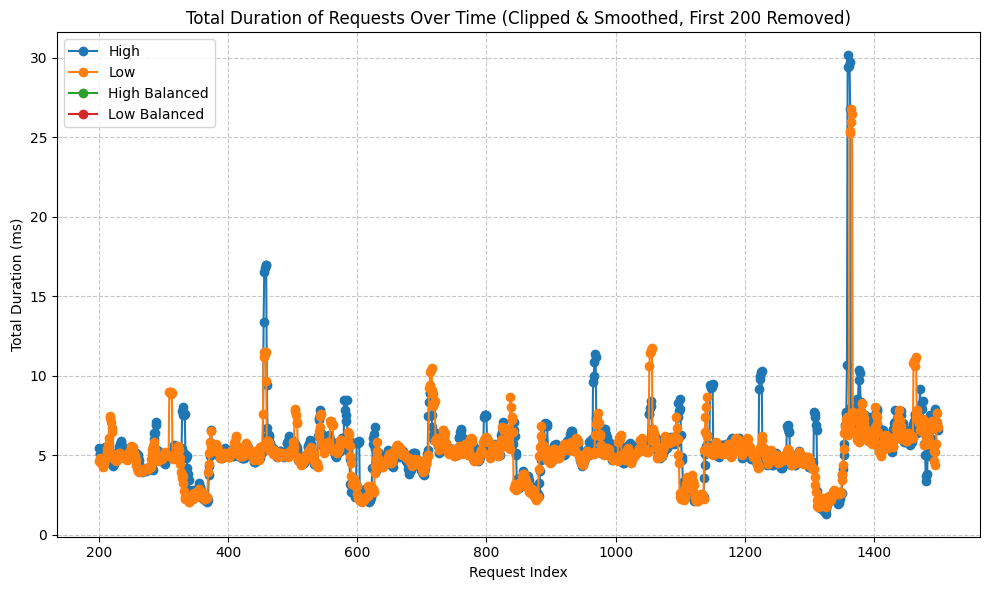

In [20]:
# Remove first 200 values
df_high = df_high.iloc[200:].reset_index(drop=True)
df_low = df_low.iloc[200:].reset_index(drop=True)
df_high_balanced = df_high_balanced.iloc[200:].reset_index(drop=True)
df_low_balanced = df_low_balanced.iloc[200:].reset_index(drop=True)

# Optional: recalculate smoothed after removing first 200 values
window = 5
for df in [df_high, df_low, df_high_balanced, df_low_balanced]:
    df['smoothed'] = df['total_duration_ms'].rolling(window=window, min_periods=1).mean()

# Plot smoothed lines
plt.figure(figsize=(10, 6))
plt.plot(df_high['request_index'], df_high['smoothed'], label='High', marker='o')
plt.plot(df_low['request_index'], df_low['smoothed'], label='Low', marker='o')
plt.plot(df_high_balanced['request_index'], df_high_balanced['smoothed'], label='High Balanced', marker='o')
plt.plot(df_low_balanced['request_index'], df_low_balanced['smoothed'], label='Low Balanced', marker='o')

plt.title('Total Duration of Requests Over Time (Clipped & Smoothed, First 200 Removed)')
plt.xlabel('Request Index')
plt.ylabel('Total Duration (ms)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('TotalDurationOverTime_Smoothed.png')
plt.show()


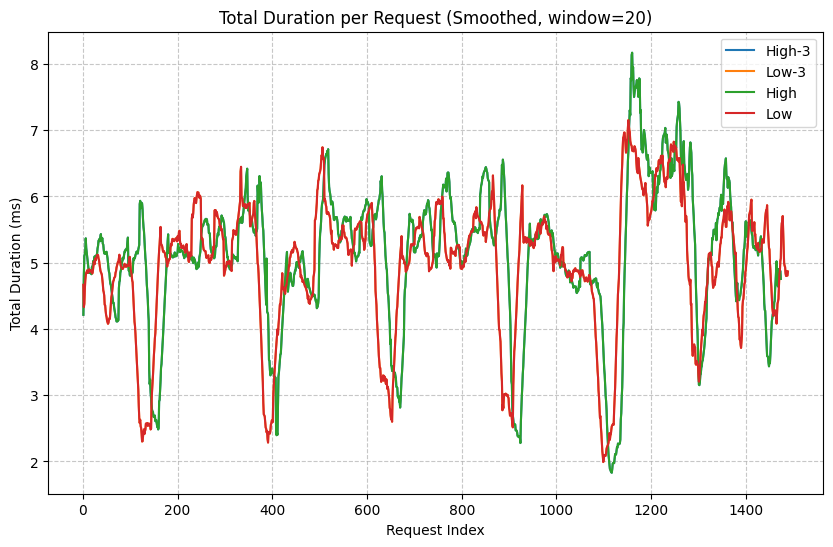

In [37]:
window_size = 20  # number of points to average over

plt.figure(figsize=(10, 6))
for label, df in dfs.items():
    smoothed = df['total_duration_ms'].rolling(window=window_size, min_periods=1).mean()
    plt.plot(df['request_index'], smoothed, label=label)

plt.title(f'Total Duration per Request (Smoothed, window={window_size})')
plt.xlabel('Request Index')
plt.ylabel('Total Duration (ms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
